In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
import joblib
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv("dataset/preprocessed_data.csv",sep=",")

In [3]:
pipe = Pipeline([
    ('scaler',RobustScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', CatBoostClassifier(iterations=800, depth=8, learning_rate=0.03, verbose=False))
])

In [4]:
target = "cardio"

x = df.drop(columns=[target]).select_dtypes(include=[np.number])
y = df[target]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, stratify=y)

In [6]:
pipe.fit(x_train,y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,sampling_strategy,'auto'
,random_state,42


In [7]:
y_pred = pipe.predict(x_test)

In [66]:
print('accuracy is:',accuracy_score(y_test,y_pred))

accuracy is: 0.7397857142857143


In [68]:
joblib.dump(pipe,'models/pipeline.joblib')

['models/pipeline.joblib']

In [8]:
y_prob = pipe.predict_proba(x_test)[:, 1]

In [13]:
y_prob

array([0.66679705, 0.32896267, 0.16484583, ..., 0.10011542, 0.35693167,
       0.36080085], shape=(14000,))

In [16]:
print("roc_auc:",roc_auc_score(y_test, y_prob))
print("precision", precision_score(y_test, y_pred))
print("recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred).tolist())

roc_auc: 0.8045268035189563
precision 0.7598016426468309
recall 0.7008290451686678
f1_score 0.7291248419956874
confusion_matrix [[5454, 1550], [2093, 4903]]


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(x_train, y_train)

y_pred_lr = logistic_pipeline.predict(x_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2))


Logistic Regression Accuracy: 73.11


In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2))


Decision Tree Accuracy: 73.48


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2))


Random Forest Accuracy: 73.57


In [20]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

svm_pipeline.fit(x_train, y_train)

y_pred_svm = svm_pipeline.predict(x_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(svm_accuracy * 100, 2))


SVM Accuracy: 73.56


In [ ]:
import json
from sklearn.metrics import roc_curve, auc

y_prob = pipe.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

roc_data = {
    "roc_auc": round(roc_auc, 3),
    "roc_curve": [
        {"fpr": float(f), "tpr": float(t)}
        for f, t in zip(fpr, tpr)
    ]
}

with open("roc_metrics.json", "w") as f:
    json.dump(roc_data, f)


In [10]:
roc_data

{'roc_auc': 0.805,
 'roc_curve': [{'fpr': 0.0, 'tpr': 0.0},
  {'fpr': 0.0, 'tpr': 0.0001429388221841052},
  {'fpr': 0.0, 'tpr': 0.002287021154945683},
  {'fpr': 0.00014277555682467162, 'tpr': 0.002287021154945683},
  {'fpr': 0.00014277555682467162, 'tpr': 0.0024299599771297883},
  {'fpr': 0.00028555111364934324, 'tpr': 0.0024299599771297883},
  {'fpr': 0.00028555111364934324, 'tpr': 0.002715837621497999},
  {'fpr': 0.00042832667047401483, 'tpr': 0.002715837621497999},
  {'fpr': 0.00042832667047401483, 'tpr': 0.00357347055460263},
  {'fpr': 0.0005711022272986865, 'tpr': 0.00357347055460263},
  {'fpr': 0.0005711022272986865, 'tpr': 0.006146369353916523},
  {'fpr': 0.0007138777841233581, 'tpr': 0.006146369353916523},
  {'fpr': 0.0007138777841233581, 'tpr': 0.006289308176100629},
  {'fpr': 0.0008566533409480297, 'tpr': 0.006289308176100629},
  {'fpr': 0.0008566533409480297, 'tpr': 0.008862206975414523},
  {'fpr': 0.001142204454597373, 'tpr': 0.008862206975414523},
  {'fpr': 0.0011422044545

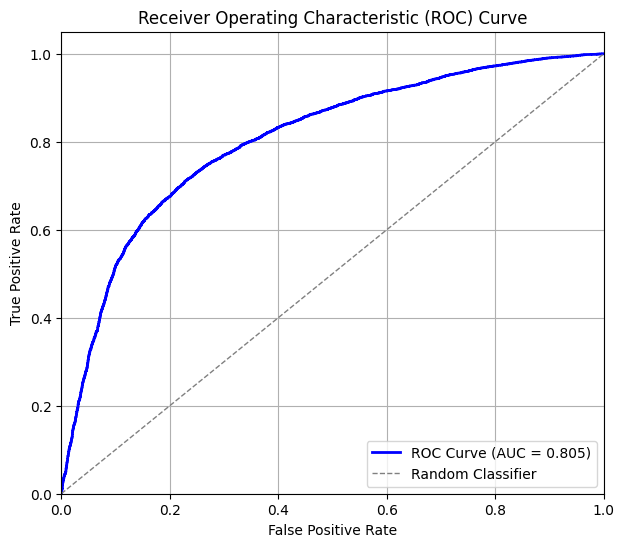

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.legend(loc="lower right")

plt.grid(True)

plt.show()